# Классификация на PyTorch Lightning


In [1]:
!pip install "pytorch-lightning>=2.0" datasets tqdm

In [2]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score


In [3]:
wine = load_wine()
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {len(np.unique(y))}")


Train: torch.Size([142, 13]), Test: torch.Size([36, 13])
Classes: 3


In [4]:
from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df["target"] = wine.target

print(df.head())
print(df.shape)
print(wine.feature_names)
print(wine.target_names)

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [5]:
print(X_train[:5])
print(y_train[:10])

tensor([[ 1.6653, -0.6084,  1.2190,  1.6054, -0.1674,  0.8040, -0.6917,  1.2672,
          1.8775,  3.4195, -1.6563, -0.8794, -0.2486],
        [-0.5495,  2.7515,  1.0033,  1.6054, -0.3044, -0.7854, -1.4012,  2.0496,
         -0.8735, -0.0248, -0.5846, -1.2546, -0.7299],
        [-0.7453, -1.1435, -0.9375, -0.2827, -0.8524,  1.9370,  1.7468, -1.0017,
          0.5880, -0.2401,  0.3585,  0.2462, -0.2486],
        [ 0.6129, -0.6172,  1.0033,  0.8792, -0.7839,  0.4893, -0.9015,  1.1890,
          1.1726,  2.8813, -1.6563, -1.1296, -0.3814],
        [ 0.1112, -0.7663, -0.9375, -1.1541, -0.1674,  0.1745,  0.6375, -0.6887,
         -0.4093, -0.5845,  0.9586,  0.1351,  0.9464]])
tensor([2, 2, 1, 2, 0, 1, 1, 1, 2, 0])


In [6]:
display(df.sample(5, random_state=42))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.10,0.96,3.36,845.0,0
45,14.21,4.04,2.44,18.9,111.0,2.85,2.65,0.30,1.25,5.24,0.87,3.33,1080.0,0
140,12.93,2.81,2.70,21.0,96.0,1.54,0.50,0.53,0.75,4.60,0.77,2.31,600.0,2
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.70,1.19,2.71,1285.0,0
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.68,1.12,3.48,510.0,1


In [7]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
import numpy as np

wine = load_wine()
X = wine.data
y = wine.target

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

class WineDataset(Dataset):
    def __init__(self, X, y):
        if torch.is_tensor(X):
            self.X = X.float().clone().detach()
        else:
            self.X = torch.tensor(X, dtype=torch.float32)
        if torch.is_tensor(y):
            self.y = y.long().clone().detach()
        else:
            self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class WineDataModule(pl.LightningDataModule):
    def __init__(self, X_train, X_val, X_test, y_train, y_val, y_test, batch_size=16):
        super().__init__()
        self.X_train = X_train
        self.X_val = X_val
        self.X_test = X_test
        self.y_train = y_train
        self.y_val = y_val
        self.y_test = y_test
        self.batch_size = batch_size

    def setup(self, stage=None):
        self.train_dataset = WineDataset(self.X_train, self.y_train)
        self.val_dataset = WineDataset(self.X_val, self.y_val)
        self.test_dataset = WineDataset(self.X_test, self.y_test)

    def train_dataloader(self):
        return DataLoader(self.train_dataset, batch_size=self.batch_size, shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, batch_size=self.batch_size)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, batch_size=self.batch_size)

class NeuralNetLightning(pl.LightningModule):
    def __init__(self, input_size, num_classes, lr=0.001):
        super().__init__()
        self.save_hyperparameters()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("train_loss", loss, prog_bar=True)
        self.log("train_acc", acc, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True)
        self.log("val_acc", acc, prog_bar=True)

    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        self.log("test_loss", loss, prog_bar=True)
        self.log("test_acc", acc, prog_bar=True)

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

data_module = WineDataModule(
    X_train=torch.FloatTensor(X_train),
    X_val=torch.FloatTensor(X_val),
    X_test=torch.FloatTensor(X_test),
    y_train=torch.LongTensor(y_train),
    y_val=torch.LongTensor(y_val),
    y_test=torch.LongTensor(y_test),
    batch_size=16
)

model = NeuralNetLightning(input_size=X_train.shape[1], num_classes=len(np.unique(y)), lr=0.001)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min"
)

checkpoint = ModelCheckpoint(
    monitor="val_loss",
    mode="min",
    save_top_k=1,
    filename="best-{epoch:02d}-{val_loss:.4f}"
)

trainer = pl.Trainer(
    max_epochs=100,
    accelerator="auto",
    devices=1,
    log_every_n_steps=5,
    enable_progress_bar=True,
    callbacks=[early_stop, checkpoint]
)

trainer.fit(model, data_module)
trainer.test(model, datamodule=data_module, ckpt_path="best")

print("Best checkpoint:", checkpoint.best_model_path)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name      ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model     │ Sequential       │  1.1 K │ train │     0 │
│ 1 │ criterion │ CrossEntropyLoss │      0 │ train │     0 │
└───┴───────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 1.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.1 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 5                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=100` reached.


INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/lightning_logs/version_6/checkpoints/best-epoch=99-val_loss=0.0240.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/lightning_logs/version_6/checkpoints/best-epoch=99-val_loss=0.0240.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9629629850387573     │
│         test_loss         │    0.06445620954036713    │
└───────────────────────────┴───────────────────────────┘

Best checkpoint: /content/lightning_logs/version_6/checkpoints/best-epoch=99-val_loss=0.0240.ckpt


In [8]:
best_model = NeuralNetLightning.load_from_checkpoint(checkpoint.best_model_path)

In [9]:
test_results = trainer.test(model, datamodule=data_module, ckpt_path="best")
print(test_results)

INFO:pytorch_lightning.utilities.rank_zero:Restoring states from the checkpoint path at /content/lightning_logs/version_6/checkpoints/best-epoch=99-val_loss=0.0240.ckpt
INFO:pytorch_lightning.utilities.rank_zero:Loaded model weights from the checkpoint at /content/lightning_logs/version_6/checkpoints/best-epoch=99-val_loss=0.0240.ckpt


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test_acc          │    0.9629629850387573     │
│         test_loss         │    0.06445620954036713    │
└───────────────────────────┴───────────────────────────┘

[{'test_loss': 0.06445620954036713, 'test_acc': 0.9629629850387573}]


In [10]:
import torch
import numpy as np

best_model = NeuralNetLightning.load_from_checkpoint(checkpoint.best_model_path)
best_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x_batch, y_batch in data_module.test_dataloader():
        logits = best_model(x_batch)
        preds = torch.argmax(logits, dim=1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

Test accuracy: 0.9629629629629629
Saved: /content/drive/MyDrive/wine_project/classification_report.csv
Saved: /content/drive/MyDrive/wine_project/test_metrics.csv


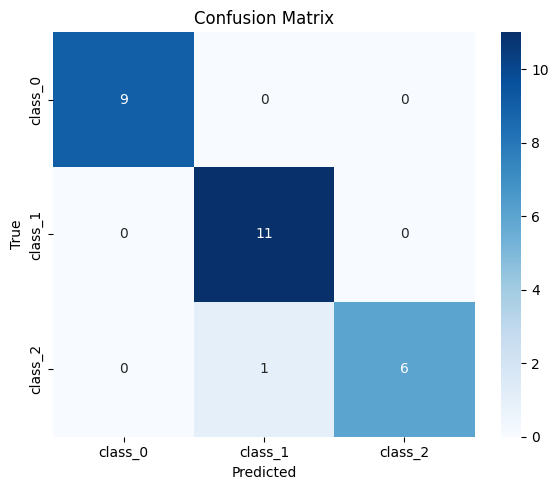

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.metrics import confusion_matrix, classification_report

save_dir = "/content/drive/MyDrive/wine_project"
os.makedirs(save_dir, exist_ok=True)

# Load best model
best_model = NeuralNetLightning.load_from_checkpoint(checkpoint.best_model_path)
best_model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x_batch, y_batch in data_module.test_dataloader():
        logits = best_model(x_batch)
        preds = torch.argmax(logits, dim=1)
        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Metrics
test_acc = (y_true == y_pred).mean()
cm = confusion_matrix(y_true, y_pred)

report = classification_report(
    y_true,
    y_pred,
    target_names=wine.target_names,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()
report_df.to_csv(f"{save_dir}/classification_report.csv", index=True)

metrics_df = pd.DataFrame([{
    "test_accuracy": test_acc
}])
metrics_df.to_csv(f"{save_dir}/test_metrics.csv", index=False)

print("Test accuracy:", test_acc)
print("Saved:", f"{save_dir}/classification_report.csv")
print("Saved:", f"{save_dir}/test_metrics.csv")

# Confusion matrix plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=wine.target_names,
    yticklabels=wine.target_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{save_dir}/confusion_matrix.png", dpi=200, bbox_inches="tight")
plt.show()